## RoPE position embeddings
In contrast to the GPT2 implementation where the position embeddings are learned, [Rotary Position Embedding (RoPE)](https://arxiv.org/abs/2104.09864) uses fixed equations for the positional embeddings. Also, GPT2 mixes positional and semantic embeddings by adding them together, RoPE instead separates out positional embeddings and applies them in the attention mechanism itself.
While the calculations introduced by RoPE are fairly straigh-forward, the intuition behind them are worth taking the time to [understand](https://towardsdatascience.com/rope-clearly-explained/).


RoPE works by rotating the $q$ and $k$ projections of each token. The amount of rotation applied depends on the absolute position $m$ of the token. Furthermore, rotation is applied non-uniformly across all the 2D pairs of vector indices, $i$, so that the first pairs of dimensions in the $q$ and $k$ vectors are rotated more than the final pairs of the vectors. This allows for specialiation as the first dimensions can primarily contribute to attention scores over shorter sequences, whereas the last dimensions can contribute even if they are remote in the sequence.

Each 2D pair is rotated by a predefined angle. The starting point is a set of angular values, $\Theta$, containing $P/2$ elements where $P$ is the per-head output dimension:
$$ \Theta = \{\theta_i = 10000^{−2(i−1)/d}, i \in [1,2,...,d/2]\} $$

For token position in the context window, a new set of angular values are generated by multiplying the orignal values by the token index. This approach ensures that nearby tokens are rotated by more similar angles than tokens further away in the seqeunce.  

The [Llama model implementation of RoPE](https://github.com/meta-llama/llama/blob/6c7fe276574e78057f917549435a2554000a876d/llama/model.py#L48) was helpful as a reference.


In [ ]:
import torch

from sturnus.models.rope import calculate_thetas, apply_rope

B = 2
C = 200
H = 3
P = 100

torch.manual_seed(42)
q = torch.rand(B, C, H, P)
k = torch.rand(B, C, H, P)

c_values, thetas = calculate_thetas(embedding_dimension=P, context_size=C)

q_ = apply_rope(q, c_values)
k_ = apply_rope(k, c_values)

In [4]:
# freqs_cis

In [5]:
c_values

tensor([[ 1.0000+0.0000e+00j,  1.0000+0.0000e+00j,  1.0000+0.0000e+00j,
          ...,  1.0000+0.0000e+00j,  1.0000+0.0000e+00j,
          1.0000+0.0000e+00j],
        [ 0.5403+8.4147e-01j,  0.6736+7.3912e-01j,  0.7701+6.3795e-01j,
          ...,  1.0000+1.7378e-04j,  1.0000+1.4454e-04j,
          1.0000+1.2023e-04j],
        [-0.4161+9.0930e-01j, -0.0926+9.9570e-01j,  0.1860+9.8254e-01j,
          ...,  1.0000+3.4756e-04j,  1.0000+2.8909e-04j,
          1.0000+2.4045e-04j],
        ...,
        [-0.6056+7.9581e-01j,  0.8801+4.7472e-01j, -0.3603-9.3284e-01j,
          ...,  0.9994+3.4228e-02j,  0.9996+2.8471e-02j,
          0.9997+2.3682e-02j],
        [-0.9968-7.9579e-02j,  0.2419+9.7029e-01j,  0.3177-9.4820e-01j,
          ...,  0.9994+3.4402e-02j,  0.9996+2.8616e-02j,
          0.9997+2.3803e-02j],
        [-0.4716-8.8180e-01j, -0.5542+8.3239e-01j,  0.8495-5.2755e-01j,
          ...,  0.9994+3.4575e-02j,  0.9996+2.8760e-02j,
          0.9997+2.3923e-02j]])

In [6]:
# (x_ == x1_).all()

In [7]:
# x.reshape(*x.shape[:-1], -1, 2)

In [8]:
# x_angles = torch.atan2(x.reshape(*x.shape[:-1], -1, 2)[...,1], x.reshape(*x.shape[:-1], -1, 2)[...,0])* 180/torch.pi
# x__angles = torch.atan2(x_.reshape(*x_.shape[:-1], -1, 2)[...,1], x_.reshape(*x_.shape[:-1], -1, 2)[...,0])* 180/torch.pi

# d_angles = x__angles - x_angles

tensor(0.)
tensor(57.2958)
tensor(114.5916)
tensor(171.8873)
tensor(229.1831)


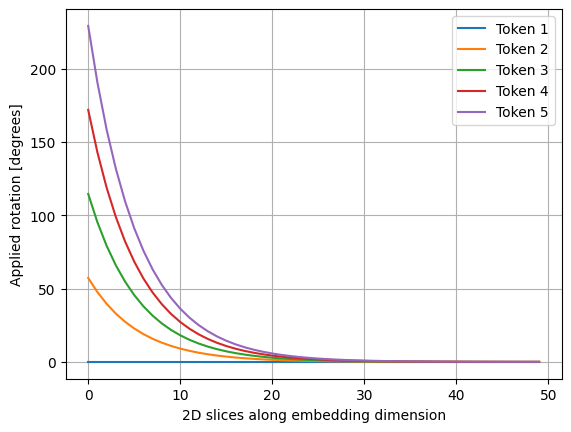

In [ ]:
fig, ax = plt.subplots()

for i in range(0, 5):
    c_b = torch.view_as_real(c_values)[i,:]
    angle = torch.atan2(c_b[:, 1], c_b[:, 0]) * 180/torch.pi
    angle[angle<0] += 360
    ax.plot(
        range(int(P/2)),
        angle,
        label=f'Token {i+1}'
    )

ax.set_xlabel('2D slices along embedding dimension')
ax.set_ylabel('Applied rotation [degrees]')
ax.grid()
ax.legend()


In [10]:
q_.shape

torch.Size([2, 200, 3, 100])

In [ ]:
def calculate_attention_scores(qi, ki):
    B, C, H, P = qi.shape

    qi = qi.transpose(1, 2)
    ki = ki.transpose(1, 2)

    attention_scores = qi @ ki.transpose(2, 3)

    return attention_scores


attention_scores = calculate_attention_scores(q, k)
attention_scores_ = calculate_attention_scores(q_, k_)

In [35]:
torch.max(q)

tensor(1.0000)

tensor(-0.8492)

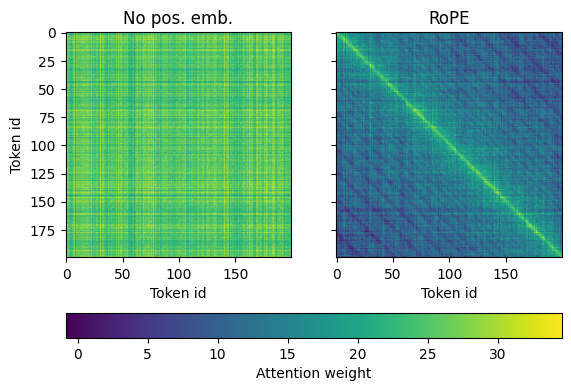

In [ ]:

import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors

fig, axs = plt.subplots(1, 2, sharey=True)



# create a colorizer with a predefined norm to be shared across all images
norm = mcolors.Normalize(
    vmin=min(torch.min(attention_scores), torch.min(attention_scores_)),
    vmax=max(torch.max(attention_scores), torch.max(attention_scores_))
)

colorizer = mcolorizer.Colorizer(norm=norm)


s = axs[0].imshow(
    attention_scores[0, 0,...], colorizer=colorizer
)
axs[1].imshow(
    attention_scores_[0, 0,...], colorizer=colorizer
)

axs[0].set_xlabel('Token id')
axs[1].set_xlabel('Token id')
axs[0].set_ylabel('Token id')

axs[0].set_title('No pos. emb.')
axs[1].set_title('RoPE')
fig.colorbar(s, ax=axs, orientation='horizontal', fraction=.1, label='Attention score')


In [ ]:

# (q_[0,:,0,:] @ k_[0,:,0,:].T).sum(dim=0)

tensor([2678.9399, 2515.5510, 2389.4409, 2139.1985, 2248.3367, 2087.4907,
        2792.0234, 2834.6733, 2040.8370, 2898.2073, 2298.9185, 2448.4290,
        2471.6704, 2605.7737, 2176.7410, 2488.6277, 2719.3755, 2763.0947,
        2697.6929, 2419.9680, 2579.8132, 2533.8650, 2621.8206, 2359.6824,
        2820.2383, 2451.9041, 2193.8005, 2394.4978, 2183.4675, 2639.0085,
        3267.2395, 2534.0808, 2761.7156, 2470.9038, 2548.1487, 2562.0142,
        2245.6243, 2365.7764, 2418.7336, 2426.0044, 2452.9399, 2984.2412,
        2824.2285, 2421.1738, 2713.3643, 2495.5378, 2867.9194, 2783.0535,
        2691.8777, 2866.0483, 2470.6211, 2643.3452, 2827.7119, 2970.5088,
        2723.5249, 2717.0378, 2285.7722, 2356.1489, 2253.2368, 2504.9043,
        2407.9556, 2595.4155, 2892.1338, 2781.3909, 2351.6348, 2649.9819,
        2372.8362, 2539.2251, 2749.2466, 3048.8992, 3085.2249, 2545.4871,
        2899.9773, 2966.0972, 2550.1362, 3017.2957, 2811.4893, 2952.2515,
        2717.6604, 2946.0439, 2708.814

In [609]:
# fig, ax = plt.subplots()

# # [B, C, H, P]
# # to_plot = d_angles[0].flatten(start_dim=0, end_dim=1)


# for i in range(5):
#     ax.plot(range(int(P/2)), d_angles[0,[i],0,:][0], label=f'Token {i+1}')
    
# ax.legend()

In [610]:
x.shape

torch.Size([2, 10, 3, 100])

In [611]:
x.shape

torch.Size([2, 10, 3, 100])

In [612]:
x_angles.shape

torch.Size([2, 10, 3, 50])

In [613]:
# B = 2
# C = 4
# H = 3
# P = 6


In [614]:
print(x__angles - x_angles)
print()

tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],

         [[ 5.7296e+01,  4.7657e+01,  3.9639e+01,  ...,  9.9602e-03,
            8.2893e-03,  6.8817e-03],
          [ 5.7296e+01,  4.7657e+01,  3.9639e+01,  ...,  9.9564e-03,
            8.2817e-03,  6.8893e-03],
          [ 5.7296e+01,  4.7657e+01,  3.9639e+01,  ...,  9.9564e-03,
            8.2817e-03,  6.8855e-03]],

         [[ 1.1459e+02,  9.5313e+01,  7.9278e+01,  ...,  1.9913e-02,
            1.6565e-02,  1.3779e-02],
          [ 1.1459e+02,  9.5313e+01,  7.9278e+01,  ...,  1.9913e-02,
            1.6567e-02,  1.3779e-02],
          [ 1.1459e+02,  9.5313e+01,  7.9278e+01,  ...,  1.9917e-02,
            1.6560e-02,  1.3783e-02]],

         ...,

         [[ 4.10

In [615]:
x_.flatten(3).shape

torch.Size([2, 10, 3, 100])

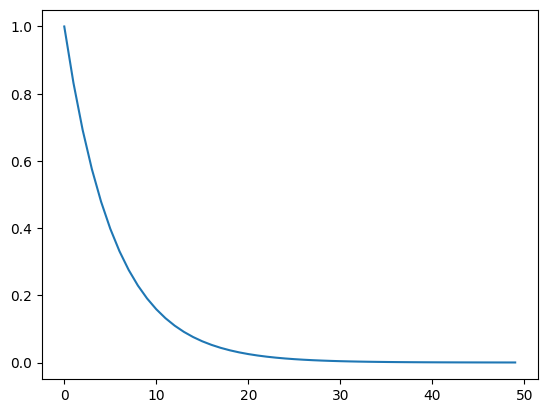

In [584]:
import matplotlib.pylab as plt


fig, ax = plt.subplots()

ax.plot(thetas)

In [282]:
c_values.shape

torch.Size([4, 3])

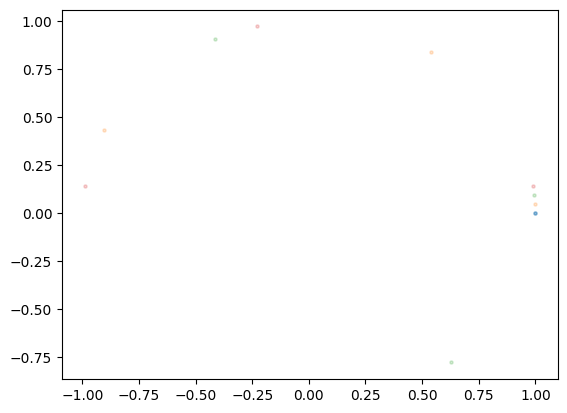

In [285]:
fig, ax = plt.subplots()

for i in range(c_values.shape[0]):
    ax.scatter(c_values[i, :].real, c_values[i, :].imag, s=5, alpha=0.2)

In [278]:
c_values

tensor([[ 1.0000+0.0000j,  1.0000+0.0000j,  1.0000+0.0000j],
        [-0.9018+0.4321j,  0.5403+0.8415j,  0.9989+0.0464j],
        [ 0.6266-0.7793j, -0.4161+0.9093j,  0.9957+0.0927j],
        [-0.2284+0.9736j, -0.9900+0.1411j,  0.9903+0.1388j]])

In [277]:
c_values.real

tensor([[ 1.0000,  1.0000,  1.0000],
        [-0.9018,  0.5403,  0.9989],
        [ 0.6266, -0.4161,  0.9957],
        [-0.2284, -0.9900,  0.9903]])

In [279]:
c_values.imag

tensor([[ 0.0000,  0.0000,  0.0000],
        [ 0.4321,  0.8415,  0.0464],
        [-0.7793,  0.9093,  0.0927],
        [ 0.9736,  0.1411,  0.1388]])

In [260]:
torch.polar?

Docstring:
polar(abs, angle, *, out=None) -> Tensor

Constructs a complex tensor whose elements are Cartesian coordinates
corresponding to the polar coordinates with absolute value :attr:`abs` and angle
:attr:`angle`.

.. math::
    \text{out} = \text{abs} \cdot \cos(\text{angle}) + \text{abs} \cdot \sin(\text{angle}) \cdot j

.. note::
    `torch.polar` is similar to
    `std::polar <https://en.cppreference.com/w/cpp/numeric/complex/polar>`_
    and does not compute the polar decomposition
    of a complex tensor like Python's `cmath.polar` and SciPy's `linalg.polar` do.
    The behavior of this function is undefined if `abs` is negative or NaN, or if `angle` is
    infinite.


Args:
    abs (Tensor): The absolute value the complex tensor. Must be float or double.
    angle (Tensor): The angle of the complex tensor. Must be same dtype as
        :attr:`abs`.

Keyword args:
    out (Tensor): If the inputs are ``torch.float32``, must be
        ``torch.complex64``. If the inputs are ``t

In [ ]:
0 <= 1

True

In [242]:
x[...,0]

tensor([[0.0560, 0.3159, 0.9938, 0.7463, 0.8087],
        [0.3355, 0.7664, 0.4474, 0.8318, 0.8030],
        [0.6083, 0.9240, 0.6289, 0.0623, 0.9927],
        [0.6567, 0.8081, 0.4059, 0.0792, 0.7781]])

In [243]:
x[:, :, 0]

tensor([[0.0560, 0.3159, 0.9938, 0.7463, 0.8087],
        [0.3355, 0.7664, 0.4474, 0.8318, 0.8030],
        [0.6083, 0.9240, 0.6289, 0.0623, 0.9927],
        [0.6567, 0.8081, 0.4059, 0.0792, 0.7781]])

In [ ]:
print(mask.any(dim=-1))
i = torch.nonzero(mask)
print(i.shape)


tensor([[False, False,  True,  True, False],
        [False,  True,  True,  True,  True]])
torch.Size([6, 3])


In [98]:
t = x[mask.any(dim=-1)]
t += 10



In [101]:
t

tensor([[10.4009, 10.4807, 10.7173, 10.8653, 10.9226, 10.0921, 10.0773, 10.4253,
         10.4619, 10.7760],
        [10.9707, 10.6284, 10.1449, 10.4434, 10.8234, 10.6845, 10.1464, 10.5292,
         10.0172, 10.2985],
        [10.0394, 10.4507, 10.0917, 10.8161, 10.1029, 10.5817, 10.7476, 10.1005,
         10.8237, 10.9072],
        [10.1935, 10.5419, 10.6516, 10.9141, 10.8906, 10.0806, 10.0925, 10.0579,
         10.2776, 10.3991],
        [10.3206, 10.8295, 10.1554, 10.1009, 10.1091, 10.2049, 10.9897, 10.5631,
         10.4125, 10.3531],
        [10.1170, 10.3304, 10.7634, 10.8379, 10.8606, 10.5356, 10.2274, 10.2048,
         10.9859, 10.0487]])

In [107]:
print('x', x.shape)
print('i', i.shape)
print('t', t.shape)


x torch.Size([2, 5, 10])
i torch.Size([6, 3])
t torch.Size([6, 10])


In [110]:
print('x', x)
print('i', i)
print('t', t)


x tensor([[[0.4158, 0.1052, 0.0745, 0.3702, 0.6384, 0.9392, 0.8677, 0.5082,
          0.1933, 0.0542],
         [0.9467, 0.2212, 0.4121, 0.0965, 0.1544, 0.5970, 0.3764, 0.5573,
          0.4962, 0.5255],
         [0.4009, 0.4807, 0.7173, 0.8653, 0.9226, 0.0921, 0.0773, 0.4253,
          0.4619, 0.7760],
         [0.9707, 0.6284, 0.1449, 0.4434, 0.8234, 0.6845, 0.1464, 0.5292,
          0.0172, 0.2985],
         [0.8497, 0.2831, 0.8053, 0.0922, 0.9421, 0.7385, 0.8240, 0.6365,
          0.5354, 0.2538]],

        [[0.2241, 0.1566, 0.9132, 0.3265, 0.5122, 0.0299, 0.6342, 0.3296,
          0.1001, 0.5619],
         [0.0394, 0.4507, 0.0917, 0.8161, 0.1029, 0.5817, 0.7476, 0.1005,
          0.8237, 0.9072],
         [0.1935, 0.5419, 0.6516, 0.9141, 0.8906, 0.0806, 0.0925, 0.0579,
          0.2776, 0.3991],
         [0.3206, 0.8295, 0.1554, 0.1009, 0.1091, 0.2049, 0.9897, 0.5631,
          0.4125, 0.3531],
         [0.1170, 0.3304, 0.7634, 0.8379, 0.8606, 0.5356, 0.2274, 0.2048,
          0.9

In [ ]:
# self[index[i][j][k]][j][k] = src[i][j][k]  # if dim == 0
# self[i][index[i][j][k]][k] = src[i][j][k]  # if dim == 1
# self[i][j][index[i][j][k]] = src[i][j][k]  # if dim == 2



In [155]:
for ii, tt in zip(i, t):
    x[ii[0]][ii[1]] = tt


In [165]:
index = ii[0:2]

In [166]:
index

tensor([1, 4])

In [185]:
index = torch.tensor([1, 4]).unsqueeze(dim=1)

In [186]:
index

tensor([[1],
        [4]])

In [188]:
x.shape

torch.Size([2, 5, 10])

In [187]:
x[index]

IndexError: index 4 is out of bounds for dimension 0 with size 2

In [139]:
ii.totuple()

AttributeError: 'Tensor' object has no attribute 'totuple'

In [152]:
print(x.shape)
# print(x)
index_tensor = ii[0:2].to(torch.long)
print(index_tensor)
print(x[index_tensor[0], index_tensor[1]])


torch.Size([2, 5, 10])
tensor([0, 2])
tensor([0.4009, 0.4807, 0.7173, 0.8653, 0.9226, 0.0921, 0.0773, 0.4253, 0.4619,
        0.7760])


In [147]:
# Create a 2D tensor of shape (5, 3)
tensor = torch.tensor([[10, 11, 12],
                       [20, 21, 22],
                       [30, 31, 32],
                       [40, 41, 42],
                       [50, 51, 52]])

# List of row indices to extract
indices = [0, 2, 4]

# Method A: Direct Bracket Indexing (Recommended)
result = tensor[indices]
# Output:
# tensor([[10, 11, 12],
#         [30, 31, 32],
#         [50, 51, 52]])

# Method B: Using torch.index_select
# Requires converting the list to a torch.LongTensor first
idx_tensor = torch.tensor(indices, dtype=torch.long)
result = torch.index_select(tensor, dim=0, index=idx_tensor)

In [120]:
x[0][2]

tensor([0.4009, 0.4807, 0.7173, 0.8653, 0.9226, 0.0921, 0.0773, 0.4253, 0.4619,
        0.7760])

In [35]:
expert_weights, expert_indices = torch.tensor([[0.4034, 0.2951],
        [0.3902, 0.2792],
        [0.4283, 0.3026],
        [0.4811, 0.2146],
        [0.5019, 0.1997]]), torch.tensor([[1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0]])

In [36]:
expert_weights, expert_indices

(tensor([[0.4034, 0.2951],
         [0.3902, 0.2792],
         [0.4283, 0.3026],
         [0.4811, 0.2146],
         [0.5019, 0.1997]]),
 tensor([[1, 0],
         [1, 0],
         [1, 0],
         [1, 0],
         [1, 0]]))

In [38]:

for i, w in zip(expert_weights, expert_indices):
    print(i, w)

tensor([0.4034, 0.2951]) tensor([1, 0])
tensor([0.3902, 0.2792]) tensor([1, 0])
tensor([0.4283, 0.3026]) tensor([1, 0])
tensor([0.4811, 0.2146]) tensor([1, 0])
tensor([0.5019, 0.1997]) tensor([1, 0])
